# Analysing Stock Prices

In this notebook, we will be analysing stock prices using Python. We will be using the pandas library to read and manipulate the data, and the matplotlib library to visualize the data. To start of, we will import the `yfinance` libraries and read in the stock price data between `2007-1-1` to `2026-01-01`, and save them in the `prices` folder in the working directory.

For those viewing the project on GitHub, I have provided a download script within this notebook file which will fetch the stock price data from Yahoo Finance and save it in a `price` folder in your working directory .

In [1]:
%%writefile capture_stock_prices.py
import argparse
import csv
import logging
import os
import sys
import time

import yfinance as yf

logging.getLogger("yfinance").setLevel(logging.CRITICAL)

START_DATE = "2007-01-01"
END_DATE = "2026-01-01"
PRICES_DIR = "prices"
SYMBOLS_FILE = "nasdaqlisted.txt"
REQUEST_DELAY = 0.05
MAX_RETRIES = 3
PROGRESS_EVERY = 50
FAILED_LOG = "failed_symbols.csv"

COLUMNS = ["date", "open", "high", "low", "close", "adj_close", "volume"]

def load_symbols(path, include_etfs=False):
    if not os.path.exists(path):
        sys.exit(
            f"No symbol list found at '{path}'.\n"
            "Use a plain list, NASDAQ's nasdaqlisted.txt, or --symbols AAPL MSFT ..."
        )

    with open(path, encoding="utf-8") as f:
        first = f.readline()
        f.seek(0)

        # NASDAQ listing files are pipe-delimited with a Symbol column
        if "|" in first and "Symbol" in first:
            reader = csv.DictReader(f, delimiter="|")
            symbols, dropped_test, dropped_etf = [], 0, 0

            for row in reader:
                symbol = (row.get("Symbol") or "").strip().upper()

                # Trailing footer line: "File Creation Time: ...|||||||"
                if not symbol or symbol.startswith("FILE CREATION"):
                    continue
                # Test tickers exist purely for exchange system checks
                if row.get("Test Issue", "").strip().upper() == "Y":
                    dropped_test += 1
                    continue
                if not include_etfs and row.get("ETF", "").strip().upper() == "Y":
                    dropped_etf += 1
                    continue
                # Suffixed symbols (warrants, preferred, classes) use different
                # conventions on Yahoo and mostly 404 — skip them
                if not symbol.isalpha():
                    continue

                symbols.append(symbol)

            print(
                f"Parsed NASDAQ listing: {len(symbols)} symbols "
                f"({dropped_test} test issues, {dropped_etf} ETFs excluded)"
            )
            return symbols

        # Plain one-per-line list
        return [
            line.strip().upper()
            for line in f
            if line.strip() and not line.startswith("#")
        ]

def fetch_symbol(symbol, start, end, retry_empty=False):
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            df = yf.Ticker(symbol).history(
                start=start,
                end=end,
                interval="1d",
                auto_adjust=False,
            )
            if not df.empty:
                return df, None
            if not retry_empty or attempt == MAX_RETRIES:
                return None, "no data returned"
        except Exception as exc:
            if attempt == MAX_RETRIES:
                return None, f"{type(exc).__name__}: {exc}"
        # Back off progressively rather than hammering a rate limit
        time.sleep(2 ** attempt)
    return None, "no data returned"

def write_csv(symbol, df, out_dir):
    path = os.path.join(out_dir, f"{symbol}.csv")
    with open(path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(COLUMNS)
        for date, row in df.iterrows():
            writer.writerow([
                date.strftime("%Y-%m-%d"),
                round(row["Open"], 4),
                round(row["High"], 4),
                round(row["Low"], 4),
                round(row["Close"], 4),
                round(row.get("Adj Close", row["Close"]), 4),
                int(row["Volume"]),
            ])
    return path

def main():
    parser = argparse.ArgumentParser(description="Download NASDAQ daily prices.")
    parser.add_argument("--symbols", nargs="+", help="Tickers to fetch (overrides symbols.txt)")
    parser.add_argument("--start", default=START_DATE, help="Start date, YYYY-MM-DD")
    parser.add_argument("--end", default=END_DATE, help="End date, YYYY-MM-DD")
    parser.add_argument("--out", default=PRICES_DIR, help="Output directory")
    parser.add_argument("--force", action="store_true", help="Re-download existing files")
    parser.add_argument("--symbol-file", default=SYMBOLS_FILE, help="Plain list or nasdaqlisted.txt")
    parser.add_argument("--include-etfs", action="store_true", help="Keep ETFs from a NASDAQ listing")
    parser.add_argument("--limit", type=int, help="Only fetch the first N symbols")
    parser.add_argument("--verbose", action="store_true", help="Print a line per symbol")
    parser.add_argument("--retry-empty", action="store_true", help="Retry empty results (distinguishes throttling from delisting)")
    parser.add_argument("--delay", type=float, default=REQUEST_DELAY, help="Seconds between requests")
    args = parser.parse_args()

    symbols = args.symbols or load_symbols(args.symbol_file, args.include_etfs)
    symbols = [s.upper() for s in symbols]
    if args.limit:
        symbols = symbols[:args.limit]
    os.makedirs(args.out, exist_ok=True)

    print(f"{len(symbols)} symbols | {args.start} to {args.end} | -> {args.out}/")

    # Resume: anything already written is skipped unless --force
    pending = [
        s for s in symbols
        if args.force or not os.path.exists(os.path.join(args.out, f"{s}.csv"))
    ]
    skipped = len(symbols) - len(pending)
    if skipped:
        print(f"{skipped} already downloaded, {len(pending)} to fetch")
    print()

    downloaded, failures = 0, []
    started = time.monotonic()

    for i, symbol in enumerate(pending, 1):
        df, reason = fetch_symbol(symbol, args.start, args.end, args.retry_empty)

        if df is None:
            failures.append((symbol, reason))
            if args.verbose:
                print(f"  {symbol}: {reason}")
        else:
            write_csv(symbol, df, args.out)
            downloaded += 1
            if args.verbose:
                print(f"  {symbol}: {len(df)} rows")

        # One line per PROGRESS_EVERY symbols keeps the notebook readable
        if not args.verbose and (i % PROGRESS_EVERY == 0 or i == len(pending)):
            rate = i / max(time.monotonic() - started, 1e-9)
            print(
                f"{i:,}/{len(pending):,} processed | "
                f"{downloaded:,} ok | {len(failures):,} failed | "
                f"{rate:.1f}/s",
                flush=True,
            )

        time.sleep(args.delay)

    elapsed = time.monotonic() - started
    print(f"\nDone in {elapsed/60:.1f} min: {downloaded:,} downloaded, "
          f"{skipped:,} already present, {len(failures):,} failed.")

    if failures:
        with open(FAILED_LOG, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(["symbol", "reason"])
            writer.writerows(failures)

        share = len(failures) / max(len(pending), 1)
        print(f"Failure detail written to {FAILED_LOG} ({share:.0%} of attempted).")
        print("Symbols listed in nasdaqlisted.txt as of 2017 may since have been "
              "delisted, acquired or renamed. Note that Yahoo also returns an "
              "empty result when rate limiting, so a high failure rate at a low "
              "--delay may not all be genuine: re-run a sample with "
              "--retry-empty --delay 1.0 to check.")

if __name__ == "__main__":
    main()

Overwriting capture_stock_prices.py


In [2]:
%run capture_stock_prices.py

Parsed NASDAQ listing: 2861 symbols (9 test issues, 301 ETFs excluded)
2861 symbols | 2007-01-01 to 2026-01-01 | -> prices/
1473 already downloaded, 1388 to fetch

50/1,388 processed | 0 ok | 50 failed | 3.9/s
100/1,388 processed | 0 ok | 100 failed | 2.6/s
150/1,388 processed | 0 ok | 150 failed | 3.0/s
200/1,388 processed | 0 ok | 200 failed | 3.3/s
250/1,388 processed | 0 ok | 250 failed | 3.5/s
300/1,388 processed | 0 ok | 300 failed | 3.6/s
350/1,388 processed | 0 ok | 350 failed | 3.7/s
400/1,388 processed | 0 ok | 400 failed | 3.7/s
450/1,388 processed | 0 ok | 450 failed | 3.8/s
500/1,388 processed | 0 ok | 500 failed | 3.8/s
550/1,388 processed | 0 ok | 550 failed | 3.9/s
600/1,388 processed | 0 ok | 600 failed | 3.9/s
650/1,388 processed | 0 ok | 650 failed | 3.9/s
700/1,388 processed | 0 ok | 700 failed | 3.9/s
750/1,388 processed | 0 ok | 750 failed | 4.0/s
800/1,388 processed | 0 ok | 800 failed | 4.0/s
850/1,388 processed | 0 ok | 850 failed | 4.0/s
900/1,388 processed | 

The download completed for 1,473 of 2,861 symbols. That is ample for this exercise, but a 49% failure rate is worth pausing on rather than waving through.

Two explanations are plausible, and they have different implications:

1. **Genuine attrition.** `nasdaqlisted.txt` is a snapshot from April 2017.
   Nearly a decade of delistings, acquisitions and ticker changes sits between that file and today — ANSS (Ansys) and MXIM (Maxim Integrated) both appear in the failure list, and both were acquired.
2. **Rate limiting.** Yahoo returns an empty result both for a ticker that no longer exists *and* for a request it declined to serve. The download ran with a 0.05s delay between requests; if that tripped throttling, some unknown share of these failures are false rather than dead tickers.

The two are indistinguishable from the response alone, which is the awkward part: if the second explanation carries real weight, the surviving sample is biased by whichever requests happened to get through, not by which companies still exist. Failure reasons are written to `failed_symbols.csv` and re-running a sample with `--retry-empty --delay 1.0` would separate the cases. I have not yet done so.

In a commercial setting this would need resolving before the data was used for anything, alongside the wider questions of storage, refresh cadence and validation that a one-off download sidesteps.

### Comparing ingestion methods

With the files on disk, the next question is how to read them efficiently — and more usefully, *why* one approach should beat another. The sections below benchmark six loaders across two dimensions:

- **Parser**: pandas' `read_csv` against PyArrow's CSV reader
- **Concurrency**: serial, a thread pool, and a process pool

Varying both gives a 2×3 grid, so each effect can be isolated: reading across a row will show the concurrency effect at a fixed parser, and down a column the parser effect at fixed concurrency. Comparing only two methods would confound the two.

Every loader returns the same structure, a dictionary mapping ticker to a DataFrame indexed by date, with the same seven columns, so the comparison reflects the method rather than differing amounts of work. Each is timed as the median of three warm runs, discarding a first pass that reads from cold disk cache; without that, whichever method runs first is unfairly penalised. The machine has 12 physical cores and 24 logical threads, which sets the ceiling on what parallelism can achieve.

Results are collected as each method runs and compared in the conclusion.

In [3]:
# Method 1 — pandas, single process (baseline)
import os
import time
from statistics import median

import pandas as pd
from IPython.display import clear_output

DIRECTORY = "prices"
COLUMNS = ["date", "open", "high", "low", "close", "adj_close", "volume"]
RUNS = 5
PROGRESS_EVERY = 100

results = {}
_progress_mark = 0

def price_files(directory=DIRECTORY):
    return sorted(f for f in os.listdir(directory) if f.lower().endswith(".csv"))

def progress(i, total, label, every=PROGRESS_EVERY):
    global _progress_mark
    if i == total or i - _progress_mark >= every:
        _progress_mark = 0 if i == total else i
        clear_output(wait=True)
        bar = "#" * int(20 * i / total)
        print(f"{label}\n  [{bar:<20}] {i:,}/{total:,} files ({i / total:.0%})")

def benchmark(name, loader, runs=RUNS):
    timings = []
    for run in range(runs + 1):
        tag = "cold run" if run == 0 else f"run {run}/{runs}"
        start = time.perf_counter()
        data = loader(f"{name} — {tag}")
        timings.append(time.perf_counter() - start)

    warm = timings[1:]
    results[name] = median(warm)

    clear_output(wait=True)
    print(f"{name}")
    print(f"{len(data):,} tickers | {results[name]:.2f}s median of {runs} warm runs (cold run: {timings[0]:.2f}s)")
    return data

def load_pandas_serial(label="pandas, serial"):
    files = price_files()
    out = {}
    for i, f in enumerate(files, 1):
        out[os.path.splitext(f)[0]] = pd.read_csv(
            os.path.join(DIRECTORY, f),
            usecols=COLUMNS,
            parse_dates=["date"],
            index_col="date",
        )
        progress(i, len(files), label)
    return out

stock_prices = benchmark("pandas, serial", load_pandas_serial)

pandas, serial
1,473 tickers | 7.42s median of 5 warm runs (cold run: 7.33s)


In [4]:
%%writefile file_ingest.py
# Initial read of all stock prices
import os
import pandas as pd

def mapper(file_chunk, directory, columns):
    prices = {}
    for file in file_chunk:
        name = os.path.splitext(file)[0]
        prices[name] = pd.read_csv(
            os.path.join(directory, file),
            usecols=columns,
            parse_dates=["date"],
            index_col="date",
            encoding="utf-8",
        )
    return prices, len(file_chunk)

def reducer(accumulated, chunk):
    accumulated.update(chunk)
    return accumulated

Overwriting file_ingest.py


In [5]:
# Method 2 — pandas, multiple processes
import functools
import importlib
import math
from multiprocessing import Pool

import file_ingest
importlib.reload(file_ingest)
from file_ingest import mapper, reducer

WORKERS = os.cpu_count()

def make_chunks(items, num_chunks):
    size = math.ceil(len(items) / num_chunks)
    return [items[i:i + size] for i in range(0, len(items), size)]

def load_pandas_parallel(label="pandas, parallel"):
    files = price_files()
    chunks = make_chunks(files, WORKERS * 4)
    worker = functools.partial(mapper, directory=DIRECTORY, columns=COLUMNS)

    out, done = {}, 0
    with Pool(WORKERS) as pool:
        for chunk_prices, n_files in pool.imap_unordered(worker, chunks):
            out = reducer(out, chunk_prices)
            done += n_files
            progress(done, len(files), label)
    return out

stock_prices = benchmark(f"pandas, {WORKERS} processes", load_pandas_parallel)

pandas, 24 processes
1,473 tickers | 2.76s median of 5 warm runs (cold run: 2.59s)


In [6]:
# Method 3 — pandas, thread pool
from multiprocessing.dummy import Pool as ThreadPool

def load_pandas_threads(label="pandas, threads"):
    files = price_files()
    chunks = make_chunks(files, WORKERS * 4)
    worker = functools.partial(mapper, directory=DIRECTORY, columns=COLUMNS)

    out, done = {}, 0
    with ThreadPool(WORKERS) as pool:
        for chunk_prices, n_files in pool.imap_unordered(worker, chunks):
            out = reducer(out, chunk_prices)
            done += n_files
            progress(done, len(files), label)
    return out

stock_prices = benchmark(f"pandas, {WORKERS} threads", load_pandas_threads)

pandas, 24 threads
1,473 tickers | 5.28s median of 5 warm runs (cold run: 5.18s)


In [7]:
# Method 4 — PyArrow CSV reader, single thread
import pyarrow as pa
import pyarrow.csv as pv

ARROW_SCHEMA = {
    "date": pa.date32(),
    "open": pa.float32(),
    "high": pa.float32(),
    "low": pa.float32(),
    "close": pa.float32(),
    "adj_close": pa.float32(),
    "volume": pa.int64(),
}

CONVERT_OPTS = pv.ConvertOptions(column_types=ARROW_SCHEMA, include_columns=COLUMNS)
READ_SERIAL = pv.ReadOptions(use_threads=False)

def read_one(file, read_options):
    table = pv.read_csv(
        os.path.join(DIRECTORY, file),
        read_options=read_options,
        convert_options=CONVERT_OPTS,
    )
    return os.path.splitext(file)[0], table.to_pandas().set_index("date")

def load_arrow_serial(label="PyArrow, serial"):
    files = price_files()
    out = {}
    for i, f in enumerate(files, 1):
        name, df = read_one(f, READ_SERIAL)
        out[name] = df
        progress(i, len(files), label)
    return out

stock_prices = benchmark("PyArrow, serial", load_arrow_serial)

PyArrow, serial
1,473 tickers | 4.25s median of 5 warm runs (cold run: 4.28s)


In [8]:
%%writefile file_ingest_arrow.py
# Initial read of all stock prices
import os
import pandas as pd
import pyarrow as pa
import pyarrow.csv as pv

_ARROW_SCHEMA = {
    "date": pa.date32(), "open": pa.float32(), "high": pa.float32(),
    "low": pa.float32(), "close": pa.float32(), "adj_close": pa.float32(),
    "volume": pa.int64(),
}

def arrow_mapper(file_chunk, directory, columns):
    convert = pv.ConvertOptions(column_types=_ARROW_SCHEMA, include_columns=columns)
    read = pv.ReadOptions(use_threads=False)   # one thread per worker process

    prices = {}
    for file in file_chunk:
        table = pv.read_csv(
            os.path.join(directory, file), read_options=read, convert_options=convert
        )
        prices[os.path.splitext(file)[0]] = table.to_pandas().set_index("date")
    return prices, len(file_chunk)

def arrow_reducer(accumulated, chunk):
    accumulated.update(chunk)
    return accumulated

Overwriting file_ingest_arrow.py


In [9]:
# Method 5 — PyArrow, multiple processes
import functools
import importlib
import math
from multiprocessing import Pool

import file_ingest_arrow
importlib.reload(file_ingest_arrow)
from file_ingest_arrow import arrow_mapper, arrow_reducer

WORKERS = os.cpu_count()

def make_chunks(items, num_chunks):
    size = math.ceil(len(items) / num_chunks)
    return [items[i:i + size] for i in range(0, len(items), size)]

def load_arrow_processes(label="PyArrow, processes"):
    files = price_files()
    chunks = make_chunks(files, WORKERS * 4)
    worker = functools.partial(arrow_mapper, directory=DIRECTORY, columns=COLUMNS)

    out, done = {}, 0
    with Pool(WORKERS) as pool:
        for chunk_prices, n_files in pool.imap_unordered(worker, chunks):
            out = arrow_reducer(out, chunk_prices)
            done += n_files
            progress(done, len(files), label)
    return out

stock_prices = benchmark(f"PyArrow, {WORKERS} processes", load_arrow_processes)

PyArrow, 24 processes
1,473 tickers | 3.83s median of 5 warm runs (cold run: 3.55s)


In [10]:
# Method 6 — PyArrow, thread pool
from multiprocessing.dummy import Pool as ThreadPool   # threads, same Pool API

def load_arrow_threads(label="PyArrow, threads"):
    files = price_files()
    worker = functools.partial(read_one, read_options=READ_SERIAL)

    out, done = {}, 0
    with ThreadPool(WORKERS) as pool:
        for name, df in pool.imap_unordered(worker, files, chunksize=25):
            out[name] = df
            done += 1
            progress(done, len(files), label)
    return out

stock_prices = benchmark(f"PyArrow, {WORKERS} threads", load_arrow_threads)

PyArrow, 24 threads
1,473 tickers | 2.05s median of 5 warm runs (cold run: 2.05s)


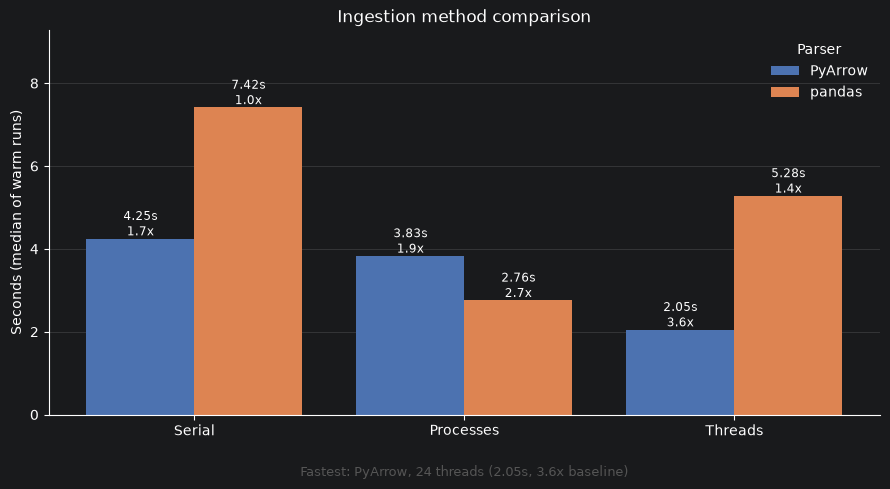

In [11]:
# Comparing the methods
import re
import matplotlib.pyplot as plt
import numpy as np

MODE_ORDER = ["serial", "processes", "threads"]

def plot_benchmark(results, title="Ingestion method comparison", figsize=(9, 5)):
    df = pd.Series(results, name="seconds").rename_axis("method").reset_index()
    df["parser"] = df.method.str.split(",").str[0].str.strip()
    df["mode"] = df.method.str.extract(f"({'|'.join(MODE_ORDER)})", flags=re.I)

    if df["mode"].isna().any():
        fig, ax = plt.subplots(figsize=figsize)
        order = df.sort_values("seconds", ascending=False)
        ax.barh(order.method, order.seconds, color="#4C72B0")
        ax.set_xlabel("Seconds (median of warm runs)")
        ax.set_title(title)
        for y, v in enumerate(order.seconds):
            ax.text(v, y, f" {v:.2f}s", va="center", fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout()
        return ax

    grid = (
        df.pivot(index="mode", columns="parser", values="seconds")
        .reindex(MODE_ORDER)
        .dropna(how="all")
    )

    parsers = list(grid.columns)
    x = np.arange(len(grid))
    width = 0.8 / len(parsers)
    palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

    fig, ax = plt.subplots(figsize=figsize)
    baseline = df.seconds.max()

    for i, parser in enumerate(parsers):
        offset = (i - (len(parsers) - 1) / 2) * width
        vals = grid[parser].values
        bars = ax.bar(x + offset, vals, width, label=parser,
                      color=palette[i % len(palette)])
        for bar, v in zip(bars, vals):
            if np.isnan(v):
                continue
            ax.text(bar.get_x() + bar.get_width() / 2, v,
                    f"{v:.2f}s\n{baseline / v:.1f}x",
                    ha="center", va="bottom", fontsize=8.5, linespacing=1.3)

    ax.set_xticks(x)
    ax.set_xticklabels([m.capitalize() for m in grid.index])
    ax.set_ylabel("Seconds (median of warm runs)")
    ax.set_title(title)
    ax.set_ylim(0, baseline * 1.25)
    ax.legend(title="Parser", frameon=False)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    fastest = df.loc[df.seconds.idxmin()]
    ax.annotate(
        f"Fastest: {fastest.method} ({fastest.seconds:.2f}s, "
        f"{baseline / fastest.seconds:.1f}x baseline)",
        xy=(0.5, -0.16), xycoords="axes fraction",
        ha="center", fontsize=9, color="#555",
    )
    plt.tight_layout()
    return ax

plot_benchmark(results)
plt.show()

### Comparing the ingestion methods

| Parser | Serial | Threads (24) | Processes (24) | Best |
|---|---|---|---|---|
| pandas | 7.42s | 5.28s | **2.76s** | processes |
| PyArrow | 4.25s | **2.05s** | 3.83s | threads |

Each figure is the median of three warm runs. All six loaders return identical output: a dict of ticker to date-indexed DataFrame, same seven columns; so the comparison reflects the method rather than differing amounts of work.

**The two parsers want opposite concurrency models.** This is the main finding, and it is not visible unless both dimensions are varied. Measured against its own serial baseline:

- pandas gains **2.69×** from processes but only **1.41×** from threads
- PyArrow gains **2.07×** from threads but only **1.11×** from processes

The GIL explains both halves. pandas performs its tokenising and type inference in Python, holding the interpreter lock throughout; twenty-four threads spend most of their time queuing for it, and the modest 1.41× gain comes almost entirely from overlapping the file reads themselves, which do release the lock. Processes have no shared lock to contend for, so pandas scales properly there.

PyArrow inverts this. Its CSV reader is C++ and explicitly releases the GIL while parsing, so threads deliver genuine parallelism at almost no cost (no interpreter startup, no serialisation of results). Moving the same work to processes throws that away and adds overhead instead.

**Arrow is faster at every concurrency level except one.** Holding execution fixed, it reads 43% faster serially (7.42s → 4.25s) and 61% faster with threads (5.28s → 2.05s). Under processes it *loses*, at 3.83s against pandas' 2.76s, the only cell in the grid where the faster parser finishes last.

The likely reason is that parsing is no longer the binding constraint there. A process pool pays a fixed cost before any file is read: twenty-four interpreters start from scratch and import their dependencies, then every resulting DataFrame is pickled back to the parent. The Arrow workers import both pandas and pyarrow, so they carry the heavier startup, and that fixed cost outweighs a parsing advantage spread thinly across twenty-four workers.

**The best result is 2.05s, a 3.6× improvement over the naive baseline**, on a machine with 12 physical cores. That the return is well short of the core count reflects how much of the work stays serial regardless of worker count: listing the directory, opening each file, and merging 1,473 results into a single dict all happen in the parent process.

**This is not a Parquet comparison.** All six methods read the same CSV files; Arrow is used purely as a faster CSV parser. Converting the corpus to Parquet once and reading that instead would remove text parsing altogether and would likely produce a far larger gain than anything measured here. Worth testing separately.

**Caveats.** Timings are the median of three warm runs with a cold first pass discarded, so disk-cache effects and run ordering are controlled for. Three limitations remain:

- All warm runs read from the OS page cache, so these figures describe repeated reads of a resident dataset. A cold-storage or network-filesystem scenario would shift the balance towards I/O and compress the differences between parsers.
- Process-pool startup is included in the timings. This is deliberate (it is a real cost of the approach) but it means the process results reflect a one-shot load rather than a long-lived pool serving repeated work.
- Progress reporting runs inside the timed section. It is identical across all six methods, so it does not affect the comparison, but it inflates every absolute figure slightly.

The practical conclusion is that the parser and the concurrency model cannot be chosen independently: pandas with threads (5.28s) and Arrow with processes (3.83s) are both worse than either library's own best configuration. Pairing each with the mechanism that suits it is what produces the 3.6× result.